# D2 · Calcium Waves in 1-D — Travelling Pulses in an Excitable Medium

**Module D — Spatio-Temporal Patterns**

In D1 we met the calcium–IP3 model and explored its single-cell dynamics:
steady states, oscillations, and excitability near the Hopf bifurcation.

Now we line up 80 cells in a chain, couple them by calcium diffusion,
and watch what happens when a small pacemaker region continuously fires.

The result is a **travelling wave** — a periodic calcium pulse that propagates
from the pacemaker through the rest of the tissue.  This is the basic mechanism
behind calcium waves in *Xenopus* oocytes, fertilisation waves in eggs,
and intercellular calcium signalling in astrocyte networks.

**Learning goals**
- Extend the single-cell IP3 ODE to a spatially extended chain.
- Understand the difference between an **oscillatory** medium (all cells fire spontaneously)
  and an **excitable** medium (cells fire only when triggered).
- Read a kymograph and extract wave speed and period.

## 1 · From Single Cell to Chain

### Single-cell model (D1 review)

$$
\dot{X}_i = a_i - \frac{m_2 X_i}{1+X_i}
  + \frac{m_3 Y_i}{k_1+Y_i}\cdot\frac{X_i^2}{k_a+X_i^2}
  + Y_i - k X_i
$$

$$
\dot{Y}_i = \frac{m_2 X_i}{1+X_i}
  - \frac{m_3 Y_i}{k_1+Y_i}\cdot\frac{X_i^2}{k_a+X_i^2} - Y_i
$$

$X$ = cytosolic Ca²⁺, $Y$ = IP₃.

### Coupling — calcium diffusion

Calcium spreads between neighbouring cells (through gap junctions or ER continuity):

$$
\dot{X}_i = f(X_i, Y_i) + D_X\underbrace{(X_{i-1} - 2X_i + X_{i+1})}_{\text{discrete Laplacian}}
$$

Only calcium ($X$) diffuses; IP₃ ($Y$) is produced and consumed locally.

### Oscillatory vs excitable medium

From D1's bifurcation scan:

| Inflow $a$ | Single-cell behaviour |
|---|---|
| $a < 0.32$ | Stable steady state — **excitable** (fires only when triggered) |
| $a \geq 0.32$ | Limit cycle — **oscillatory** (fires spontaneously) |

We set the **bulk** cells just below threshold ($a=0.31$, excitable) and
the **pacemaker** cells above it ($a=0.34$, oscillating).

The pacemaker fires periodically and each calcium pulse triggers its
excitable neighbours — which trigger their neighbours — propagating a wave.
Unlike phase waves in a purely oscillatory medium, these are
**true propagating fronts**: each cell fires, enters a refractory period,
and cannot be retriggered until it recovers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

# ── Model parameters (identical to D1) ───────────────────────────────────────
PARAMS = dict(m2=20, m3=23, ka=0.8, k=0.8, k1=0.8)

def calcium_ip3(t, state, a, m2, m3, ka, k, k1):
    X, Y = state
    ip3 = (m3 * Y / (k1 + Y)) * X**2 / (ka + X**2)
    dX  = a - m2*X/(1+X) + ip3 + Y - k*X
    dY  =     m2*X/(1+X) - ip3     - Y
    return [dX, dY]

print("Model loaded.  Oscillatory threshold: a ≈ 0.32")

Model loaded.  Oscillatory threshold: a ≈ 0.32


## 2 · Chain Setup

In [10]:
# ── Chain parameters ──────────────────────────────────────────────────────────
N        = 80      # number of cells
D_X      = 1.0     # calcium diffusion coefficient
N_PACE   = 5       # pacemaker cells at the left end
A_PACE   = 0.35    # pacemaker inflow  (oscillatory, period ≈ 10)
A_BULK   = 0.31    # bulk inflow       (excitable, below threshold)

# ── ODE for the full chain ────────────────────────────────────────────────────
def chain_rhs(t, y, N, a_arr, p, D_X):
    X, Y  = y[:N], y[N:]
    ip3   = (p['m3']*Y/(p['k1']+Y)) * X**2/(p['ka']+X**2)
    dX    = a_arr - p['m2']*X/(1+X) + ip3 + Y - p['k']*X
    dY    =         p['m2']*X/(1+X) - ip3     - Y
    Xpad  = np.pad(X, 1, mode='edge')          # no-flux boundaries
    dX   += D_X * (Xpad[:-2] - 2*X + Xpad[2:])
    return np.concatenate([dX, dY])

# ── Spatially varying inflow ──────────────────────────────────────────────────
a_arr = np.full(N, A_BULK)
a_arr[:N_PACE] = A_PACE

# ── Initial conditions: all cells at the excitable steady state ───────────────
y0 = np.concatenate([np.full(N, 0.48), np.full(N, 2.54)])

print(f"Chain: {N} cells")
print(f"Pacemaker: cells 0–{N_PACE-1}  (a = {A_PACE}, oscillatory)")
print(f"Bulk:      cells {N_PACE}–{N-1}  (a = {A_BULK}, excitable)")
print(f"Calcium diffusion: D_X = {D_X}")

Chain: 80 cells
Pacemaker: cells 0–4  (a = 0.35, oscillatory)
Bulk:      cells 5–79  (a = 0.31, excitable)
Calcium diffusion: D_X = 1.0


In [11]:
T_END = 200
print(f"Integrating {N} cells for t = 0 … {T_END} …")

sol = solve_ivp(
    chain_rhs, (0, T_END), y0,
    args=(N, a_arr, PARAMS, D_X),
    method='LSODA', dense_output=True,
    rtol=1e-6, atol=1e-8,
)
print(f"Done.  {sol.message}")

# Evaluate on a regular grid
N_T    = 2000
t_eval = np.linspace(0, T_END, N_T)
Y_out  = sol.sol(t_eval)
X_xt   = Y_out[:N, :]      # calcium: shape (cells, timepoints)

Integrating 80 cells for t = 0 … 200 …
Done.  The solver successfully reached the end of the integration interval.


## 3 · Kymograph

Each row is one cell; colour is Ca²⁺ concentration.
Bright diagonals = wave fronts travelling from left (pacemaker) to right (bulk).

- **Stripe slope** → wave speed (cells per time unit).
- **Stripe spacing along time axis** → oscillation period ≈ 10.
- The first wave takes time to cross the chain; subsequent waves follow steadily.

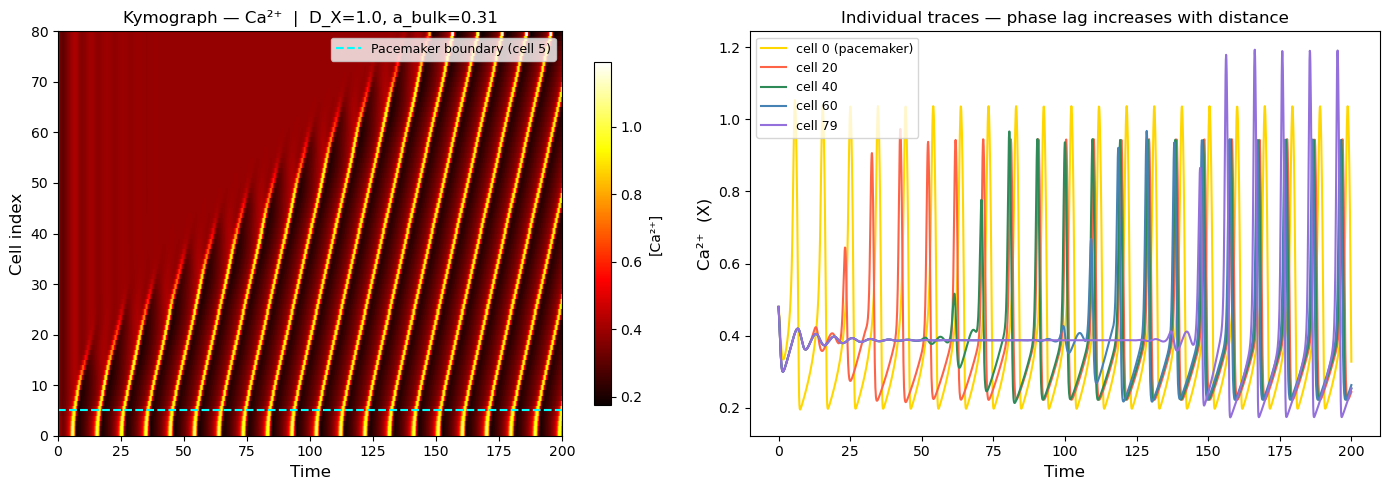

First wave: cell 0 → cell 79 in 141.5 time units
Wave speed: 0.56 cells / time unit
Pacemaker period: 9.6 time units


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: kymograph ───────────────────────────────────────────────────────────
ax = axes[0]
im = ax.imshow(X_xt, aspect='auto', origin='lower',
               extent=[0, T_END, 0, N],
               cmap='hot', interpolation='nearest',
               vmin=X_xt.min(), vmax=X_xt.max())
ax.axhline(N_PACE, color='cyan', lw=1.5, ls='--',
           label=f'Pacemaker boundary (cell {N_PACE})')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Cell index', fontsize=12)
ax.set_title(f'Kymograph — Ca²⁺  |  D_X={D_X}, a_bulk={A_BULK}', fontsize=12)
ax.legend(fontsize=9)
plt.colorbar(im, ax=ax, label='[Ca²⁺]', shrink=0.85)

# ── Right: individual traces ──────────────────────────────────────────────────
ax2 = axes[1]
for ci, col in zip([0, 20, 40, 60, 79],
                   ['gold', 'tomato', 'seagreen', 'steelblue', 'mediumpurple']):
    label = f'cell {ci}' + (' (pacemaker)' if ci < N_PACE else '')
    ax2.plot(t_eval, X_xt[ci], color=col, lw=1.5, label=label)
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('Ca²⁺  (X)', fontsize=12)
ax2.set_title('Individual traces — phase lag increases with distance', fontsize=12)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Wave speed estimate ───────────────────────────────────────────────────────
# Time for first peak to travel from cell 0 to cell 79
pk0,  _ = find_peaks(X_xt[0],  prominence=0.2)
pk79, _ = find_peaks(X_xt[79], prominence=0.2)
if len(pk0) > 0 and len(pk79) > 0:
    travel_time = t_eval[pk79[0]] - t_eval[pk0[0]]
    speed = (79 - 0) / travel_time
    period = np.mean(np.diff(t_eval[pk0])) if len(pk0) > 1 else float('nan')
    print(f"First wave: cell 0 → cell 79 in {travel_time:.1f} time units")
    print(f"Wave speed: {speed:.2f} cells / time unit")
    print(f"Pacemaker period: {period:.1f} time units")

## 4 · Exploration

Return to the **Chain parameters** cell and try the following.

| Experiment | Change | What to observe |
|---|---|---|
| **Faster diffusion** | `D_X = 5.0` | Wave travels faster; stripes steepen |
| **Slower diffusion** | `D_X = 0.5` | Wave travels slower or may fail to propagate |
| **All oscillatory** | `A_BULK = 0.33` | All cells fire spontaneously → synchronisation |
| **Further below threshold** | `A_BULK = 0.28` | Bulk less excitable; wave may die out |
| **Larger pacemaker** | `N_PACE = 15` | Wider initiation zone; same wave speed |
| **Two pacemakers** | `a_arr[75:] = 0.34` after setting up | Waves collide and annihilate |

**Two-pacemaker collision** is particularly informative: unlike sound waves,
calcium wave fronts annihilate on collision because both media enter
refractory state simultaneously.  This is a hallmark of excitable-medium waves.

## Summary

| Feature | Calcium wave (excitable) | Phase wave (oscillatory) |
|---|---|---|
| Requires pacemaker? | Yes | Yes (without symmetry breaking: synchrony) |
| Wave speed | Set by diffusion + kinetics | Set by phase gradient |
| Collision | **Annihilation** | Pass through each other |
| Refractory period | Yes — cells cannot re-fire immediately | No |

The excitable mechanism produces **robust, unidirectional** wave trains —
exactly the behaviour observed in biological calcium signalling.

**Connection to D3**: placing the same model on a 2-D grid with a circular
pacemaker produces **target patterns** (concentric rings).
Breaking the rotational symmetry of the pacemaker generates **spiral waves**
that rotate indefinitely — the spectacular patterns seen in *Dictyostelium*
and cardiac tissue.